In [1]:
import numpy as np
import matplotlib.pyplot as plt

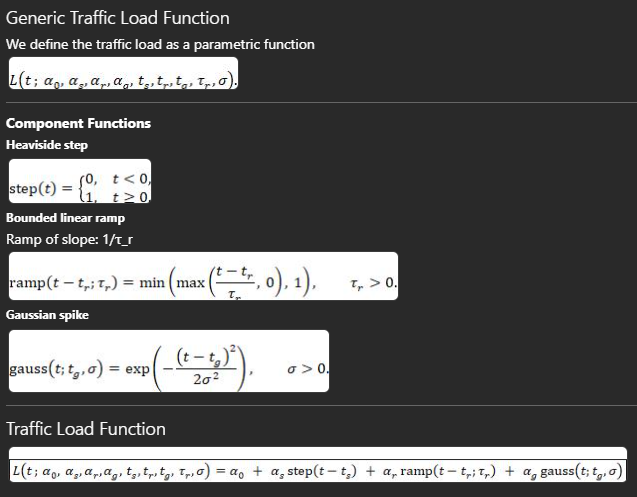

In [2]:
class TrafficLoad:
    def __init__(self, alpha_0, alpha_s, alpha_r, alpha_g, t_s, t_r, t_g, tau_r, sigma):
        assert alpha_0 >= 0
        assert alpha_s >= 0
        assert alpha_r >= 0
        assert alpha_g >= 0
        assert tau_r > 0 # 1/tau_r must be a positive slope

        self.alpha_0 = alpha_0
        self.alpha_s = alpha_s
        self.alpha_r = alpha_r
        self.alpha_g = alpha_g
        self.t_s = t_s
        self.t_r = t_r
        self.t_g = t_g
        self.tau_r = tau_r
        self.sigma = sigma

        # Upper bound on maximum possible rate
        self.rate_max = self.alpha_0 + self.alpha_s + self.alpha_r + self.alpha_g
    
    def step(self, t):
        return float(t - self.t_s >= 0) # step(t_s) defined as 1

    def ramp(self, t):
        return min(1, max(0, (t - self.t_r) / self.tau_r))

    def gaussian(self, t):
        return np.exp(-0.5 * ((t - self.t_g) / self.sigma) ** 2)

    def __call__(self, t):
        return self.alpha_0 + self.alpha_s * self.step(t) + self.alpha_r * self.ramp(t) + self.alpha_g * self.gaussian(t)


(0.0, 50.0)

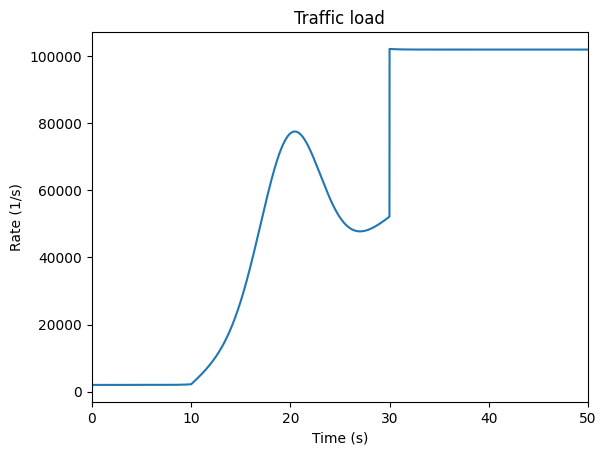

In [3]:
alpha_0, alpha_s, alpha_r, alpha_g, t_s, t_r, t_g, tau_r, sigma = 2000, 50000, 50000, 50000, 30, 10, 20, 20, 3
t_end = 50
load = TrafficLoad(alpha_0, alpha_s, alpha_r, alpha_g, t_s, t_r, t_g, tau_r, sigma)

t = np.linspace(0, t_end, 5000)
l = [load(x) for x in t]
plt.plot(t, l)
plt.title("Traffic load")
plt.xlabel("Time (s)")
plt.ylabel("Rate (1/s)")
plt.xlim([0, t_end])

In [4]:
def simulate_nonhomogeneous_poisson(rate, t_end, seed=None):
    """
    Generate samples from a non-homogeneous Poisson process with a given rate function.
    """
    rng = np.random.default_rng(seed)
    rate_max = rate.rate_max
    times = []
    t = 0
    while True:
        # Propose next inter-arrival time from exponential distribution at the max rate.
        t += rng.exponential(1 / rate_max)
        if t > t_end:
            break
        # Poisson process thinning. Accepted samples distributed as Poisson(rate(t)) with p = rate(t) / rate_max.
        if rng.uniform(0, 1) < rate(t) / rate_max:
            times.append(t)
    return times

In [5]:
times = simulate_nonhomogeneous_poisson(load, t_end)
print(len(times))

2976671


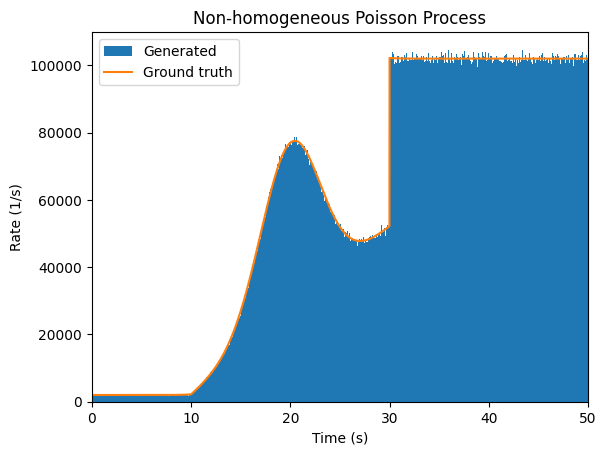

In [6]:
bins = 500
counts, edges = np.histogram(times, bins=bins)
_ = plt.stairs(bins * counts / t_end, edges=edges, fill=True, label="Generated")

t = np.linspace(0, t_end, 5000)
l = [load(x) for x in t]
plt.plot(t, l, label="Ground truth")
plt.title("Non-homogeneous Poisson Process")
plt.xlabel("Time (s)")
plt.ylabel("Rate (1/s)")

plt.xlim([0, t_end])
plt.legend()